# 03. 모델 실험

### 실험 순서
1. 데이터 로드 및 PyTorch Dataset/DataLoader 구성
2. LSTM 대조군 학습
3. Transformer (수치 전용) 학습
4. 성능 비교 및 시각화
5. 모델 저장

---
## 1. 데이터 로드 및 설정

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import sys

sys.path.insert(0, str(Path('..').resolve()))
from src.utils.metrics import regression_metrics, port_metrics
from src.utils.visualize import plot_predictions, plot_loss_curve, plot_model_comparison
from src.models.lstm import build_lstm
from src.models.transformer import build_transformer

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

PROCESSED = Path('../data/processed')
MODELS_DIR = Path('../data/processed/models')
MODELS_DIR.mkdir(exist_ok=True)

# 데이터 로드
X_train = np.load(PROCESSED / 'X_train.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
X_val   = np.load(PROCESSED / 'X_val.npy')
y_val   = np.load(PROCESSED / 'y_val.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

print(f'Train: X{X_train.shape} y{y_train.shape}')
print(f'Val  : X{X_val.shape} y{y_val.shape}')
print(f'Test : X{X_test.shape} y{y_test.shape}')

N_FEATURES  = X_train.shape[2]
N_PORTS     = y_train.shape[2]
PRED_HORIZON = y_train.shape[1]
TARGET_PORTS = ['부산', '울산', '인천', '광양']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n피처 수: {N_FEATURES}, 항만 수: {N_PORTS}, horizon: {PRED_HORIZON}')
print(f'Device: {DEVICE}')

Train: X(506, 30, 57) y(506, 7, 4)
Val  : X(63, 30, 57) y(63, 7, 4)
Test : X(64, 30, 57) y(64, 7, 4)

피처 수: 57, 항만 수: 4, horizon: 7
Device: cpu


In [2]:
def make_loader(X, y, batch_size=32, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)
print('DataLoader 구성 완료')

DataLoader 구성 완료


---
## 2. 학습 함수

In [3]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=15):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_loss += criterion(model(X_batch), y_batch).item()

        tl = epoch_loss / len(train_loader)
        vl = val_loss   / len(val_loader)
        train_losses.append(tl)
        val_losses.append(vl)
        scheduler.step(vl)

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Train: {tl:.4f} | Val: {vl:.4f}')

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
            trues.append(y_batch.numpy())
    return np.concatenate(trues), np.concatenate(preds)

---
## 3. LSTM 대조군 학습

In [4]:
lstm_model = build_lstm(
    n_features=N_FEATURES,
    n_ports=N_PORTS,
    pred_horizon=PRED_HORIZON,
    hidden_size=128,
    num_layers=2,
    dropout=0.2,
)
n_params = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM 파라미터 수: {n_params:,}')

lstm_model, lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader, epochs=150, lr=1e-3, patience=20
)

torch.save(lstm_model.state_dict(), MODELS_DIR / 'lstm_best.pt')
print('LSTM 모델 저장 완료')

LSTM 파라미터 수: 231,452


Epoch  10 | Train: 0.0124 | Val: 0.0022


Epoch  20 | Train: 0.0109 | Val: 0.0035


Epoch  30 | Train: 0.0098 | Val: 0.0036


Early stop at epoch 31
LSTM 모델 저장 완료


In [5]:
y_true_test, lstm_preds = evaluate(lstm_model, test_loader)
lstm_metrics = regression_metrics(y_true_test, lstm_preds)
lstm_port    = port_metrics(y_true_test, lstm_preds, TARGET_PORTS)

print('=== LSTM 테스트 성능 ===')
for k, v in lstm_metrics.items():
    print(f'  {k}: {v:.4f}')
print('\n항만별 RMSE:')
for port, v in lstm_port.items():
    print(f'  {port}: {v:.4f}')

=== LSTM 테스트 성능 ===
  MAE: 0.0892
  RMSE: 0.1278
  MAPE: 49.3842

항만별 RMSE:
  부산: 0.1333
  울산: 0.1690
  인천: 0.0494
  광양: 0.1287


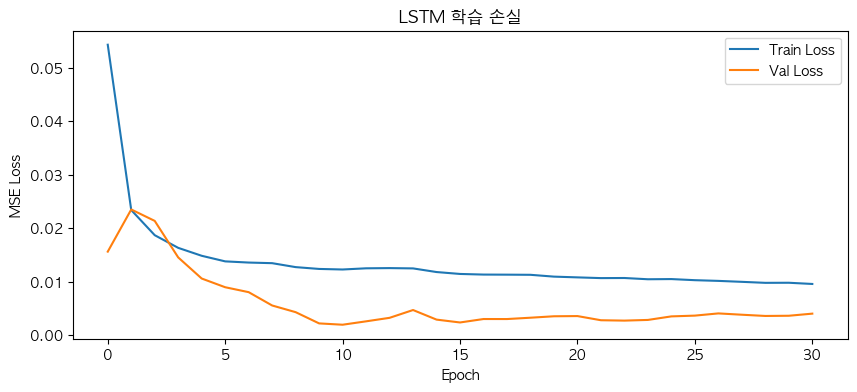

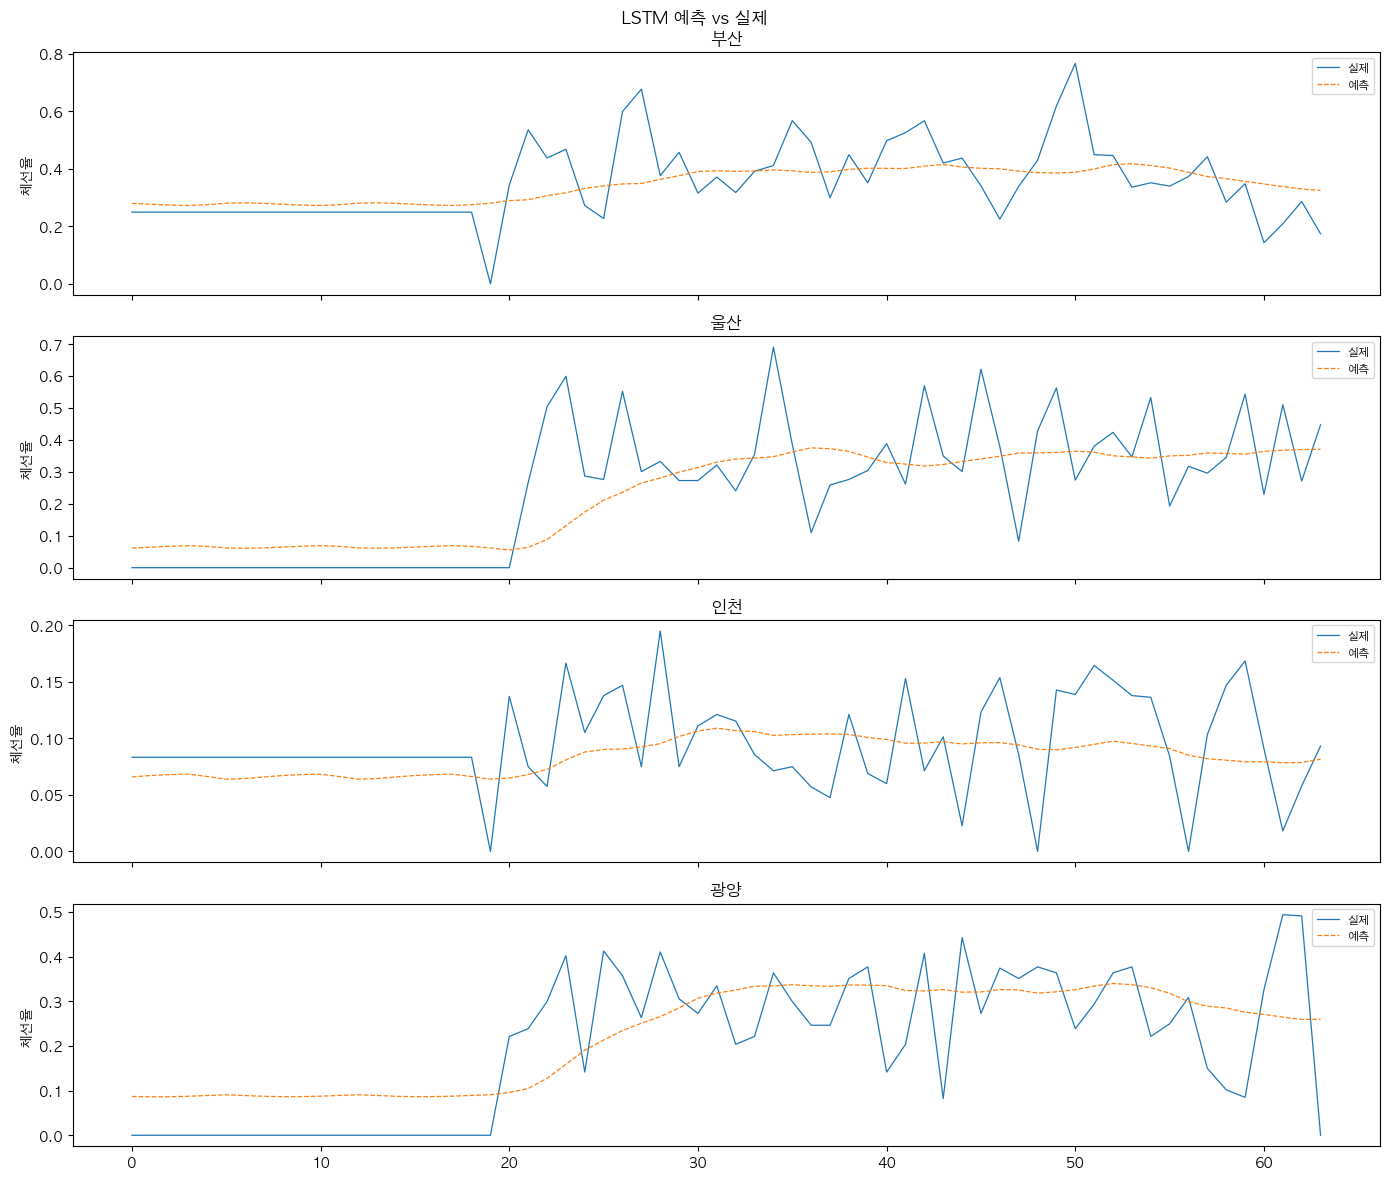

In [6]:
fig = plot_loss_curve(lstm_train_losses, lstm_val_losses, 'LSTM 학습 손실')
plt.show()

fig = plot_predictions(y_true_test, lstm_preds, TARGET_PORTS, title='LSTM 예측 vs 실제')
plt.show()

---
## 4. Transformer (수치 전용) 학습

In [7]:
# 경량화: 샘플 수(506) 대비 파라미터 최소화 → 오버피팅 방지
# d_model=64, layers=2, ff=128 → 약 82,000 파라미터 (기존 422,000 → 5배 감소)
tf_model = build_transformer(
    n_features=N_FEATURES,
    n_ports=N_PORTS,
    pred_horizon=PRED_HORIZON,
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
)
n_params = sum(p.numel() for p in tf_model.parameters())
print(f'Transformer 파라미터 수: {n_params:,} (경량화 버전)')

tf_model, tf_train_losses, tf_val_losses = train_model(
    tf_model, train_loader, val_loader, epochs=200, lr=5e-4, patience=25
)

torch.save(tf_model.state_dict(), MODELS_DIR / 'transformer_best.pt')
print('Transformer 모델 저장 완료')

/Users/hyunkio/Desktop/berth_forecast/src/models/transformer.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)


Transformer 파라미터 수: 76,636 (경량화 버전)


Epoch  10 | Train: 0.0161 | Val: 0.0098


Epoch  20 | Train: 0.0131 | Val: 0.0071


Epoch  30 | Train: 0.0118 | Val: 0.0053


Epoch  40 | Train: 0.0115 | Val: 0.0109


Epoch  50 | Train: 0.0108 | Val: 0.0093


Epoch  60 | Train: 0.0102 | Val: 0.0093


Early stop at epoch 64
Transformer 모델 저장 완료


In [8]:
y_true_test, tf_preds = evaluate(tf_model, test_loader)
tf_metrics = regression_metrics(y_true_test, tf_preds)
tf_port    = port_metrics(y_true_test, tf_preds, TARGET_PORTS)

print('=== Transformer 테스트 성능 ===')
for k, v in tf_metrics.items():
    print(f'  {k}: {v:.4f}')
print('\n항만별 RMSE:')
for port, v in tf_port.items():
    print(f'  {port}: {v:.4f}')

=== Transformer 테스트 성능 ===
  MAE: 0.0901
  RMSE: 0.1241
  MAPE: 50.3859

항만별 RMSE:
  부산: 0.1350
  울산: 0.1549
  인천: 0.0477
  광양: 0.1308


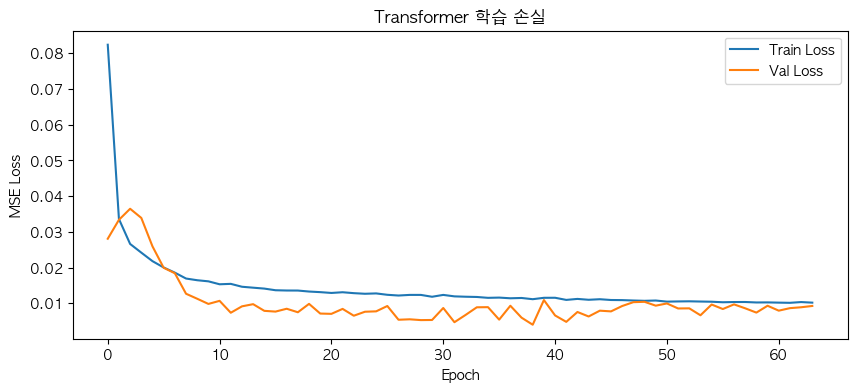

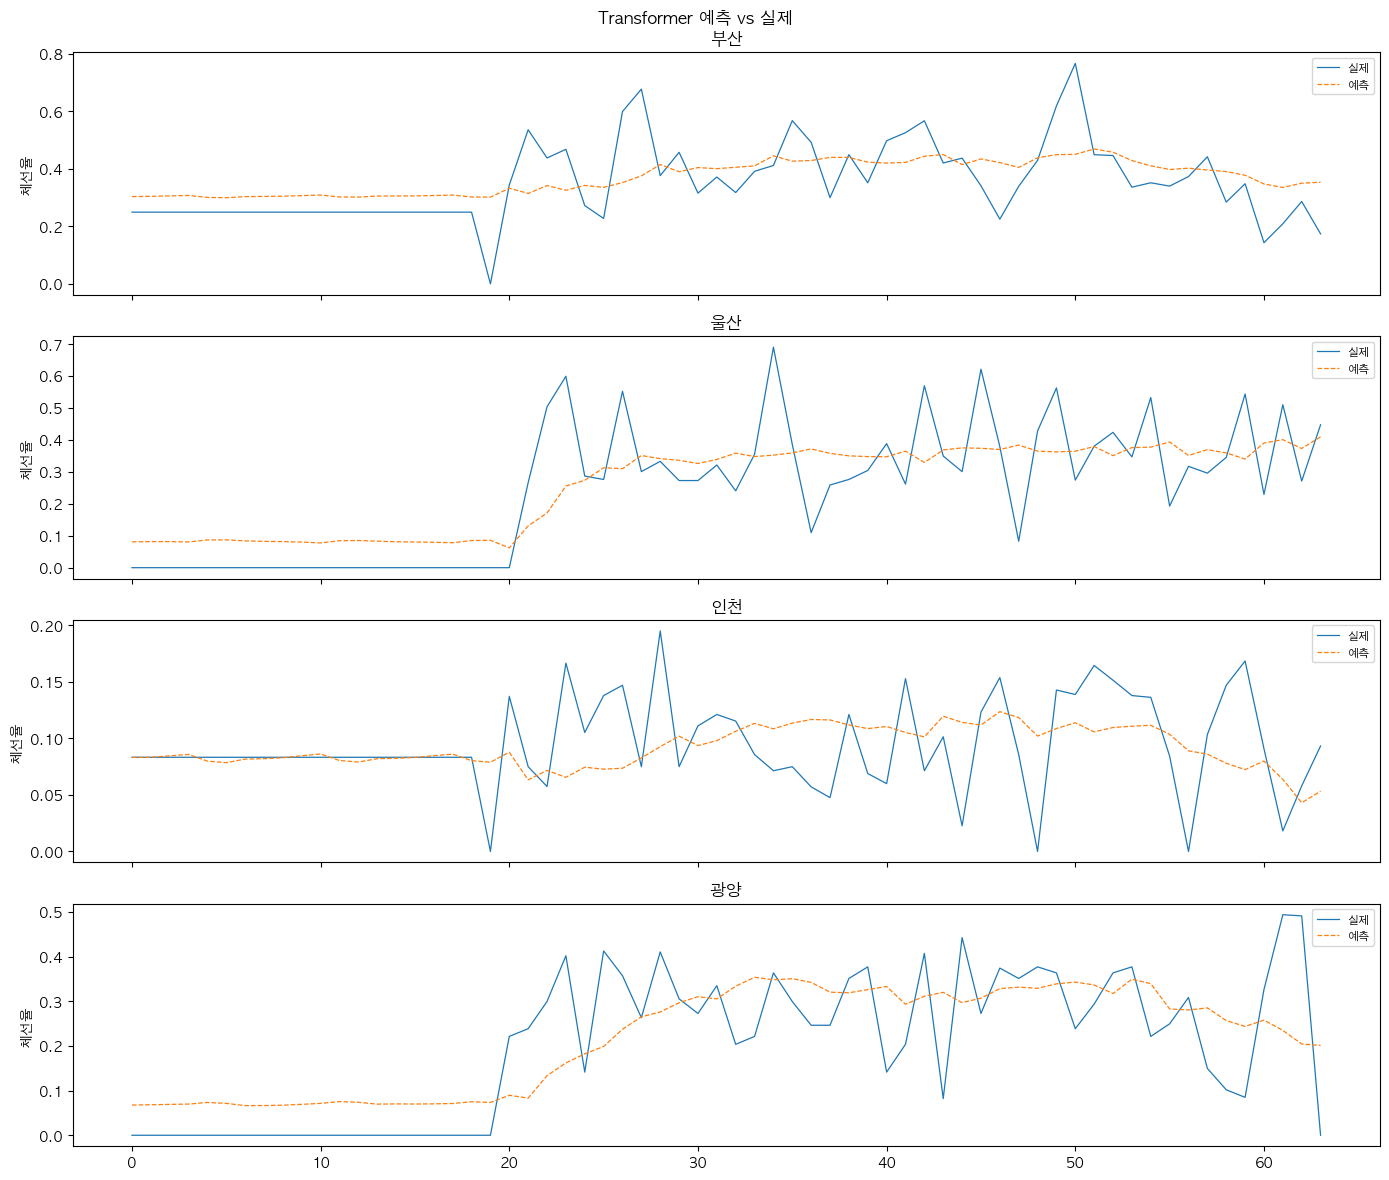

In [9]:
fig = plot_loss_curve(tf_train_losses, tf_val_losses, 'Transformer 학습 손실')
plt.show()

fig = plot_predictions(y_true_test, tf_preds, TARGET_PORTS, title='Transformer 예측 vs 실제')
plt.show()

---
## 5. 모델 성능 비교

> **MAPE 주의사항**: 체선율이 0인 날(16%)에서 분모=0 → MAPE 수치 불안정(50% 내외).
> 주 지표는 **MAE·RMSE** 사용. MAPE는 참고용.

In [10]:
import pandas as pd

comparison = pd.DataFrame({
    'LSTM (대조군)':  lstm_metrics,
    'Transformer':    tf_metrics,
}).T

print('=== 모델 성능 비교 표 ===')
print(comparison.round(4).to_string())

rmse_improvement = (lstm_metrics['RMSE'] - tf_metrics['RMSE']) / lstm_metrics['RMSE'] * 100
print(f'\nRMSE 개선율 (LSTM → Transformer): {rmse_improvement:.1f}%')
print(f'  ※ MAPE는 0값 많아 불안정 — MAE/RMSE 위주 해석')

# 항만별 RMSE
port_comp = pd.DataFrame({
    'LSTM': lstm_port,
    'Transformer': tf_port,
})
port_comp['개선율(%)'] = ((port_comp['LSTM'] - port_comp['Transformer']) / port_comp['LSTM'] * 100).round(1)
print('\n항만별 RMSE:')
print(port_comp.round(4).to_string())

=== 모델 성능 비교 표 ===
                MAE    RMSE     MAPE
LSTM (대조군)   0.0892  0.1278  49.3842
Transformer  0.0901  0.1241  50.3859

RMSE 개선율 (LSTM → Transformer): 2.9%
  ※ MAPE는 0값 많아 불안정 — MAE/RMSE 위주 해석

항만별 RMSE:
      LSTM  Transformer  개선율(%)
부산  0.1333       0.1350    -1.3
울산  0.1690       0.1549     8.3
인천  0.0494       0.0477     3.4
광양  0.1287       0.1308    -1.6


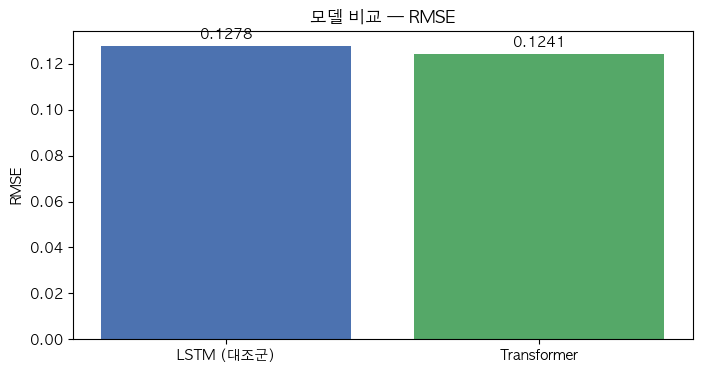

비교 결과 저장: data/processed/model_comparison.csv


In [11]:
fig = plot_model_comparison(
    {'LSTM (대조군)': lstm_metrics['RMSE'], 'Transformer': tf_metrics['RMSE']},
    metric='RMSE'
)
plt.show()

# 결과 저장
comparison.to_csv(PROCESSED / 'model_comparison.csv', encoding='utf-8-sig')
print('비교 결과 저장: data/processed/model_comparison.csv')

--- 
## 5.5. Transformer + 이벤트 피처 학습

> 이벤트 피처(strike/weather/surge/any_event) 4개 추가 → n_features=61

In [12]:
# 이벤트 포함 데이터 로드
import pathlib
PROCESSED = pathlib.Path("../data/processed")
ev_meta_path = PROCESSED / "dataset_ev_meta.json"

if not ev_meta_path.exists():
    print("[경고] 이벤트 데이터셋이 없습니다.")
    print("  02_feature_engineering.ipynb 셀 19~24를 먼저 실행하세요.")
else:
    import json as _json
    with open(ev_meta_path) as _f:
        ev_meta = _json.load(_f)
    N_FEATURES_EV = ev_meta["n_features"]

    X_ev_train = np.load(PROCESSED / "X_ev_train.npy")
    y_ev_train = np.load(PROCESSED / "y_ev_train.npy")
    X_ev_val   = np.load(PROCESSED / "X_ev_val.npy")
    y_ev_val   = np.load(PROCESSED / "y_ev_val.npy")
    X_ev_test  = np.load(PROCESSED / "X_ev_test.npy")
    y_ev_test  = np.load(PROCESSED / "y_ev_test.npy")

    ev_train_loader = make_loader(X_ev_train, y_ev_train, shuffle=True)
    ev_val_loader   = make_loader(X_ev_val,   y_ev_val)
    ev_test_loader  = make_loader(X_ev_test,  y_ev_test)

    print(f"이벤트 포함 피처 수: {N_FEATURES_EV}")
    print(f"Train {X_ev_train.shape} / Val {X_ev_val.shape} / Test {X_ev_test.shape}")

이벤트 포함 피처 수: 61
Train (506, 30, 61) / Val (63, 30, 61) / Test (64, 30, 61)


In [13]:
# Transformer + 이벤트 피처 학습
tf_ev_model = build_transformer(
    n_features=N_FEATURES_EV,
    n_ports=N_PORTS,
    pred_horizon=PRED_HORIZON,
    d_model=64,
    nhead=4,
    num_encoder_layers=2,
    dim_feedforward=128,
    dropout=0.1,
)
print(f"Transformer+Event 파라미터: {sum(p.numel() for p in tf_ev_model.parameters()):,}")

tf_ev_model, tf_ev_train_losses, tf_ev_val_losses = train_model(
    tf_ev_model, ev_train_loader, ev_val_loader,
    epochs=150, lr=5e-4, patience=15,
)
torch.save(tf_ev_model.state_dict(), MODELS_DIR / "transformer_event_best.pt")
print("Transformer+Event 모델 저장 완료")


Transformer+Event 파라미터: 76,892


/Users/hyunkio/Desktop/berth_forecast/src/models/transformer.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)


Epoch  10 | Train: 0.0167 | Val: 0.0101


Epoch  20 | Train: 0.0136 | Val: 0.0071


Epoch  30 | Train: 0.0122 | Val: 0.0084


Early stop at epoch 39
Transformer+Event 모델 저장 완료


Transformer + 이벤트 피처 테스트 성능:
  MAE: 0.0949
  RMSE: 0.1338
  MAPE: 55.5905


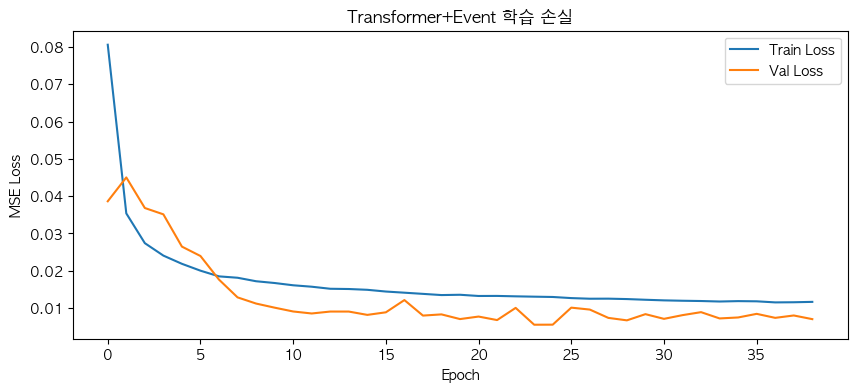

In [14]:
# Transformer+Event 평가
y_true_ev_test, tf_ev_preds = evaluate(tf_ev_model, ev_test_loader)
tf_ev_metrics = regression_metrics(y_true_ev_test, tf_ev_preds)

print("Transformer + 이벤트 피처 테스트 성능:")
for k, v in tf_ev_metrics.items():
    print(f"  {k}: {v:.4f}")

fig = plot_loss_curve(tf_ev_train_losses, tf_ev_val_losses, "Transformer+Event 학습 손실")
plt.show()


--- 
## 6. 3-Way 최종 비교 (LSTM vs Transformer vs Transformer+Event)

In [15]:
import pandas as pd

comparison = pd.DataFrame({
    "LSTM (대조군)":      lstm_metrics,
    "Transformer":        tf_metrics,
    "Transformer+Event":  tf_ev_metrics,
})
print(comparison.T.to_string())

base_rmse  = lstm_metrics["RMSE"]
tf_imp     = (base_rmse - tf_metrics["RMSE"])    / base_rmse * 100
tf_ev_imp  = (base_rmse - tf_ev_metrics["RMSE"]) / base_rmse * 100
ev_add_imp = (tf_metrics["RMSE"] - tf_ev_metrics["RMSE"]) / tf_metrics["RMSE"] * 100

print(f"LSTM to Transformer RMSE: {tf_imp:.1f}%")
print(f"LSTM to Transformer+Event RMSE: {tf_ev_imp:.1f}%")
print(f"Event feature gain: {ev_add_imp:.1f}%")


                        MAE      RMSE       MAPE
LSTM (대조군)         0.089199  0.127786  49.384218
Transformer        0.090083  0.124096  50.385934
Transformer+Event  0.094947  0.133825  55.590463
LSTM to Transformer RMSE: 2.9%
LSTM to Transformer+Event RMSE: -4.7%
Event feature gain: -7.8%


항만별 RMSE:
        LSTM  Transformer  Transformer+Event
부산  0.133252     0.135020           0.137130
울산  0.168966     0.154892           0.174323
인천  0.049361     0.047694           0.048613
광양  0.128745     0.130776           0.141703


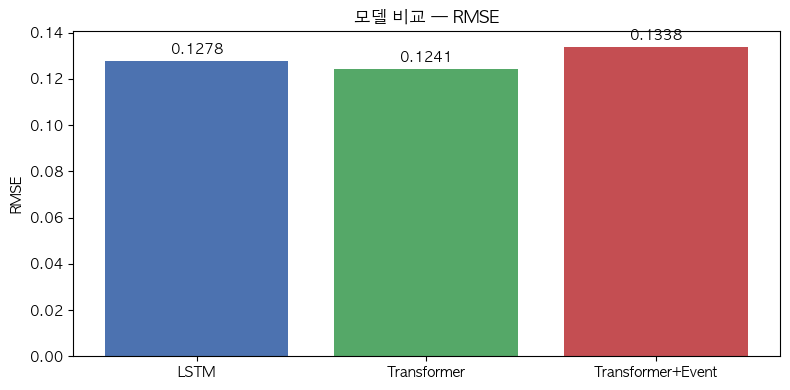

In [16]:
# 항만별 RMSE 비교
PORT_NAMES = ["부산", "울산", "인천", "광양"]

port_results = {}
for model_name, (y_t, y_p) in [
    ("LSTM",              (y_true_test, lstm_preds)),
    ("Transformer",       (y_true_test, tf_preds)),
    ("Transformer+Event", (y_true_ev_test, tf_ev_preds)),
]:
    port_results[model_name] = port_metrics(y_t, y_p, PORT_NAMES)

port_df = pd.DataFrame(port_results)
print("항만별 RMSE:")
print(port_df.to_string())

# 시각화
fig = plot_model_comparison(
    {
        "LSTM":              lstm_metrics["RMSE"],
        "Transformer":       tf_metrics["RMSE"],
        "Transformer+Event": tf_ev_metrics["RMSE"],
    },
    metric="RMSE"
)
plt.tight_layout()
plt.show()


In [17]:
# 최종 비교 결과 저장
comparison.T.to_csv(PROCESSED / "model_comparison_3way.csv", encoding="utf-8-sig")
print("3-way 비교 결과 저장: data/processed/model_comparison_3way.csv")


3-way 비교 결과 저장: data/processed/model_comparison_3way.csv
